**Dereck Axel Pineda Retureta**
           A01644658

In [ ]:
#Create the link between your drive and google colab

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


RESULTADOS:
    Verde: 6
  Naranja: 9
 Amarillo: 5
     Azul: 7
     Rojo: 4
    TOTAL: 31


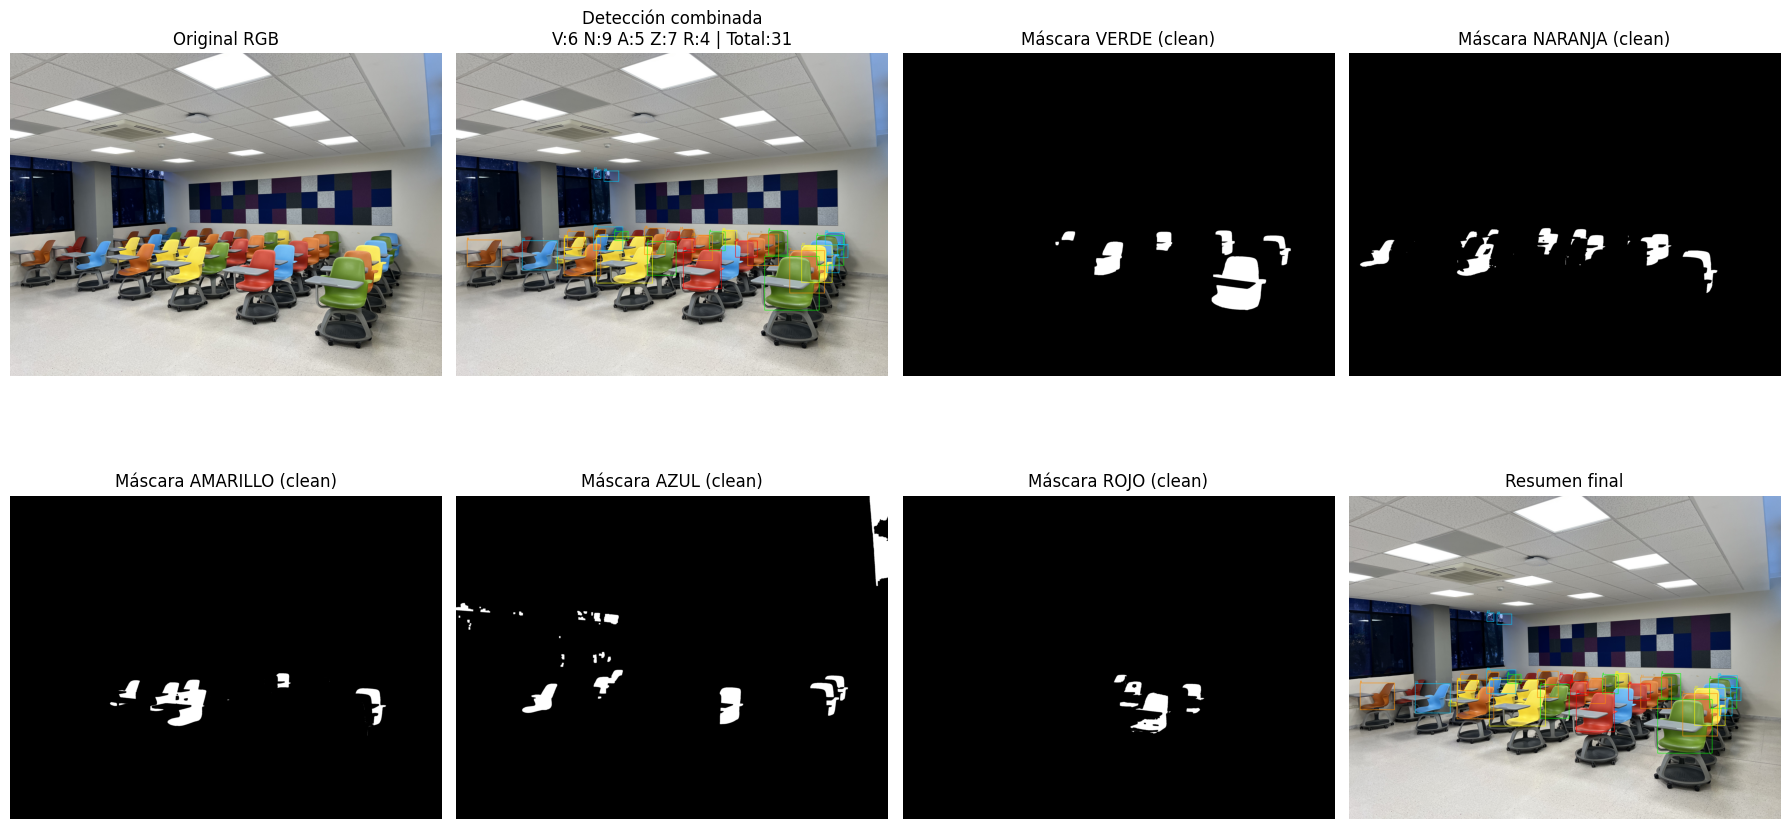

In [ ]:
#Contador de sillas por color: verde, naranja, amarillo, azul, rojo

 # - conteo por color
 # - total global
 # - figura resumen con bounding boxes combinados

  #Requisitos:
      #pip install opencv-python numpy matplotlib

from __future__ import annotations

from dataclasses import dataclass
from typing import List, Tuple, Dict

import cv2
import numpy as np
import matplotlib.pyplot as plt



#Imagen para Analizar

IMAGE_PATH = (
    "/content/drive/MyDrive/Semestre5SemanaTec2/"
    "Evidencia FINAL/IMG_EVIDENCIA/IMG_6.jpg"
)


@dataclass
class ColorSpec:

    #Especificación para detección de sillas de un color dado.

   # Atributos importantes:
   # - hsv_ranges: lista de (low, high) en HSV. Para colores tipo rojo que
   #   "cruzan" el hue 180°, damos dos rangos.
   # - draw_bgr: color de dibujo para las cajas.
   #  - merge_iou: si >0, fusiona cajas que se traslapan para no contar respaldo+asiento doble.

    name: str
    hsv_ranges: List[Tuple[np.ndarray, np.ndarray]]
    draw_bgr: Tuple[int, int, int]
    min_area: int = 800
    max_area: int | None = None
    aspect_min: float = 0.4
    aspect_max: float = 2.0
    min_h: int = 0

    # Morfología base
    close_kernel: Tuple[int, int] = (5, 5)
    close_iter: int = 2
    open_kernel: Tuple[int, int] = (3, 3)
    open_iter: int = 1

    # Extra opcional (dilatación, erosión)
    dilate_kernel: Tuple[int, int] | None = None
    dilate_iter: int = 0
    erode_kernel: Tuple[int, int] | None = None
    erode_iter: int = 0

    # Fusión de cajas por IoU
    merge_iou: float = 0.0


def make_mask(
    hsv_img: np.ndarray,
    ranges: List[Tuple[np.ndarray, np.ndarray]]
) -> np.ndarray:

    # Combina varios rangos HSV en una sola máscara binaria.

    masks = [cv2.inRange(hsv_img, low, high) for (low, high) in ranges]
    mask_out = masks[0].copy()
    for m in masks[1:]:
        mask_out = cv2.bitwise_or(mask_out, m)
    return mask_out


def clean_mask(mask_in: np.ndarray, spec: ColorSpec) -> np.ndarray:

   # Aplica operaciones morfológicas definidas en el spec:
   # close -> open -> dilate -> erode (si están configuradas).

    mask = mask_in

    if spec.close_iter > 0:
        k_close = np.ones(spec.close_kernel, np.uint8)
        mask = cv2.morphologyEx(
            mask, cv2.MORPH_CLOSE, k_close, iterations=spec.close_iter
        )

    if spec.open_iter > 0:
        k_open = np.ones(spec.open_kernel, np.uint8)
        mask = cv2.morphologyEx(
            mask, cv2.MORPH_OPEN, k_open, iterations=spec.open_iter
        )

    if spec.dilate_kernel and spec.dilate_iter > 0:
        k_dil = np.ones(spec.dilate_kernel, np.uint8)
        mask = cv2.dilate(mask, k_dil, iterations=spec.dilate_iter)

    if spec.erode_kernel and spec.erode_iter > 0:
        k_ero = np.ones(spec.erode_kernel, np.uint8)
        mask = cv2.erode(mask, k_ero, iterations=spec.erode_iter)

    return mask


def iou(
    box_a: Tuple[int, int, int, int],
    box_b: Tuple[int, int, int, int]
) -> float:

   # Calcula Intersection over Union (IoU) entre dos bounding boxes
   # en formato (x, y, w, h).

    x_a, y_a, w_a, h_a = box_a
    x_b, y_b, w_b, h_b = box_b

    xa1, ya1, xa2, ya2 = x_a, y_a, x_a + w_a, y_a + h_a
    xb1, yb1, xb2, yb2 = x_b, y_b, x_b + w_b, y_b + h_b

    x1 = max(xa1, xb1)
    y1 = max(ya1, yb1)
    x2 = min(xa2, xb2)
    y2 = min(ya2, yb2)

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h

    if inter_area == 0:
        return 0.0

    area_a = w_a * h_a
    area_b = w_b * h_b
    union_area = area_a + area_b - inter_area
    if union_area <= 0:
        return 0.0

    return inter_area / float(union_area)


def merge_overlapping_boxes(
    boxes: List[Tuple[int, int, int, int]],
    thr: float
) -> List[Tuple[int, int, int, int]]:

   # Junta cajas que se traslapan mucho (IoU > thr). Usado en naranja
   # para unir respaldo y asiento y contarlo como una silla.

    merged: List[Tuple[int, int, int, int]] = []

    for box in boxes:
        bx, by, bw, bh = box
        did_merge = False

        for i, keep in enumerate(merged):
            if iou(box, keep) > thr:
                kx, ky, kw, kh = keep

                x_min = min(bx, kx)
                y_min = min(by, ky)
                x_max = max(bx + bw, kx + kw)
                y_max = max(by + bh, ky + kh)

                merged[i] = (x_min, y_min, x_max - x_min, y_max - y_min)
                did_merge = True
                break

        if not did_merge:
            merged.append(box)

    return merged


def find_chair_boxes(
    mask: np.ndarray,
    spec: ColorSpec
) -> List[Tuple[int, int, int, int]]:

   # Encuentra bounding boxes candidatas a sillas, filtrando por área,
   # relación de aspecto y altura mínima.

    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    boxes: List[Tuple[int, int, int, int]] = []

    for contour in contours:
        area = cv2.contourArea(contour)

        if area < spec.min_area:
            continue
        if spec.max_area is not None and area > spec.max_area:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        if h < spec.min_h:
            continue

        if h == 0:
            continue

        aspect = w / float(h)

        if not (spec.aspect_min < aspect < spec.aspect_max):
            continue

        boxes.append((x, y, w, h))

    # Cajas traslapadas (por ejemplo respaldo+asiento)
    if spec.merge_iou > 0.0 and len(boxes) > 1:
        boxes = merge_overlapping_boxes(boxes, spec.merge_iou)

    return boxes


def draw_boxes(
    base_img_rgb: np.ndarray,
    boxes: List[Tuple[int, int, int, int]],
    color_bgr: Tuple[int, int, int],
    start_idx: int = 1
) -> np.ndarray:

   # Dibuja rectángulos y numeración sobre una copia de la imagen.
   # La numeración es continua empezando en start_idx.

    out = base_img_rgb.copy()
    idx = start_idx

    for (x, y, w, h) in boxes:
        cv2.rectangle(
            out,
            (x, y),
            (x + w, y + h),
            color_bgr,
            3
        )
        cv2.putText(
            out,
            f"{idx}",
            (x, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            color_bgr,
            2,
            cv2.LINE_AA
        )
        idx += 1

    return out


def main() -> None:
    # Cargar imagen
    img_bgr = cv2.imread(IMAGE_PATH)
    if img_bgr is None:
        raise ValueError("No se pudo leer la imagen. Revisa la ruta.")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Definiciones por color

    # Verde
    green = ColorSpec(
        name="verde",
        hsv_ranges=[
            (np.array([35, 80, 50], dtype=np.uint8),
             np.array([85, 255, 255], dtype=np.uint8)),
        ],
        draw_bgr=(0, 255, 0),
        min_area=1500,
        aspect_min=0.4,
        aspect_max=2.0,
        # morph
        close_kernel=(7, 7),
        close_iter=2,
        open_kernel=(7, 7),
        open_iter=1,
        dilate_kernel=(7, 7),
        dilate_iter=2,
        merge_iou=0.0,
    )

    # Naranja (incluye 2 rangos + fusión IoU)
    orange = ColorSpec(
        name="naranja",
        hsv_ranges=[
            # naranja brillante
            (np.array([12, 140, 140], dtype=np.uint8),
             np.array([22, 255, 255], dtype=np.uint8)),
            # naranja en sombra
            (np.array([8, 80, 60], dtype=np.uint8),
             np.array([20, 255, 200], dtype=np.uint8)),
        ],
        draw_bgr=(255, 140, 0),
        min_area=800,
        aspect_min=0.4,
        aspect_max=2.0,
        close_kernel=(5, 5),
        close_iter=2,
        open_kernel=(3, 3),
        open_iter=1,
        merge_iou=0.30,  # une respaldo + asiento
    )

    # Amarillo
    yellow = ColorSpec(
        name="amarillo",
        hsv_ranges=[
            (np.array([20, 100, 100], dtype=np.uint8),
             np.array([35, 255, 255], dtype=np.uint8)),
        ],
        draw_bgr=(255, 255, 0),
        min_area=800,
        aspect_min=0.4,
        aspect_max=2.0,
        close_kernel=(5, 5),
        close_iter=2,
        open_kernel=(3, 3),
        open_iter=1,
        erode_kernel=(3, 3),
        erode_iter=1,
        merge_iou=0.0,
    )

    # Azul (más estricto para no agarrar todo)
    blue = ColorSpec(
        name="azul",
        hsv_ranges=[
            (np.array([95, 90, 90], dtype=np.uint8),
             np.array([130, 255, 255], dtype=np.uint8)),
        ],
        draw_bgr=(0, 200, 255),  # cian-ish
        min_area=2000,
        max_area=40000,
        aspect_min=0.6,
        aspect_max=1.6,
        min_h=40,
        close_kernel=(7, 7),
        close_iter=2,
        open_kernel=(7, 7),
        open_iter=1,
        dilate_kernel=(7, 7),
        dilate_iter=1,
        merge_iou=0.0,
    )

    # Rojo (dos rangos de H y erosión suave para separar sillas pegadas)
    red = ColorSpec(
        name="rojo",
        hsv_ranges=[
            # rojo bajo
            (np.array([0, 150, 150], dtype=np.uint8),
             np.array([8, 255, 255], dtype=np.uint8)),
            # rojo alto (cierra hue H cerca de 180)
            (np.array([170, 150, 150], dtype=np.uint8),
             np.array([180, 255, 255], dtype=np.uint8)),
        ],
        draw_bgr=(255, 0, 0),
        min_area=800,
        aspect_min=0.4,
        aspect_max=2.0,
        close_kernel=(5, 5),
        close_iter=2,
        open_kernel=(3, 3),
        open_iter=1,
        erode_kernel=(3, 3),
        erode_iter=1,
        merge_iou=0.0,
    )

    specs = [green, orange, yellow, blue, red]

    #Proceso por color
    per_color_boxes: Dict[str, List[Tuple[int, int, int, int]]] = {}
    per_color_masks_clean: Dict[str, np.ndarray] = {}
    composite = img_rgb.copy()

    running_idx = 1

    for spec in specs:
        # 1. máscara cruda (puede tener varios rangos HSV)
        mask_raw = make_mask(img_hsv, spec.hsv_ranges)

        # 2. máscara limpia según morfología
        mask_clean = clean_mask(mask_raw, spec)
        per_color_masks_clean[spec.name] = mask_clean

        # 3. bounding boxes candidatos a sillas
        boxes = find_chair_boxes(mask_clean, spec)
        per_color_boxes[spec.name] = boxes

        # 4. dibujar sobre el compuesto con numeración continua
        composite = draw_boxes(
            composite,
            boxes,
            spec.draw_bgr,
            start_idx=running_idx
        )

        running_idx += len(boxes)

    #Resultados
    counts = {color: len(bxs) for color, bxs in per_color_boxes.items()}
    total_count = sum(counts.values())

    print("RESULTADOS:")
    print(f"{'Verde':>9}: {counts['verde']}")
    print(f"{'Naranja':>9}: {counts['naranja']}")
    print(f"{'Amarillo':>9}: {counts['amarillo']}")
    print(f"{'Azul':>9}: {counts['azul']}")
    print(f"{'Rojo':>9}: {counts['rojo']}")
    print(f"{'TOTAL':>9}: {total_count}")

    # Visualización
    # Layout 2 filas x 4 columnas:
    # 1: Original
    # 2: Resultado combinado
    # 3..7: máscaras limpias de cada color
    # 8: texto de resumen final incrustado en imagen compuesta otra vez
    plt.figure(figsize=(18, 10))

    plt.subplot(2, 4, 1)
    plt.title("Original RGB")
    plt.imshow(img_rgb)
    plt.axis("off")

    plt.subplot(2, 4, 2)
    plt.title(
        "Detección combinada\n"
        f"V:{counts['verde']} N:{counts['naranja']} "
        f"A:{counts['amarillo']} Z:{counts['azul']} "
        f"R:{counts['rojo']} | Total:{total_count}"
    )
    plt.imshow(composite)
    plt.axis("off")

    plt.subplot(2, 4, 3)
    plt.title("Máscara VERDE (clean)")
    plt.imshow(per_color_masks_clean["verde"], cmap="gray")
    plt.axis("off")

    plt.subplot(2, 4, 4)
    plt.title("Máscara NARANJA (clean)")
    plt.imshow(per_color_masks_clean["naranja"], cmap="gray")
    plt.axis("off")

    plt.subplot(2, 4, 5)
    plt.title("Máscara AMARILLO (clean)")
    plt.imshow(per_color_masks_clean["amarillo"], cmap="gray")
    plt.axis("off")

    plt.subplot(2, 4, 6)
    plt.title("Máscara AZUL (clean)")
    plt.imshow(per_color_masks_clean["azul"], cmap="gray")
    plt.axis("off")

    plt.subplot(2, 4, 7)
    plt.title("Máscara ROJO (clean)")
    plt.imshow(per_color_masks_clean["rojo"], cmap="gray")
    plt.axis("off")

    # slot 8: simplemente volvemos a mostrar composite por estética
    plt.subplot(2, 4, 8)
    plt.title("Resumen final")
    plt.imshow(composite)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


RESULTADOS:
    Verde: 7
  Naranja: 5
 Amarillo: 7
     Azul: 9
     Rojo: 5
    TOTAL: 33


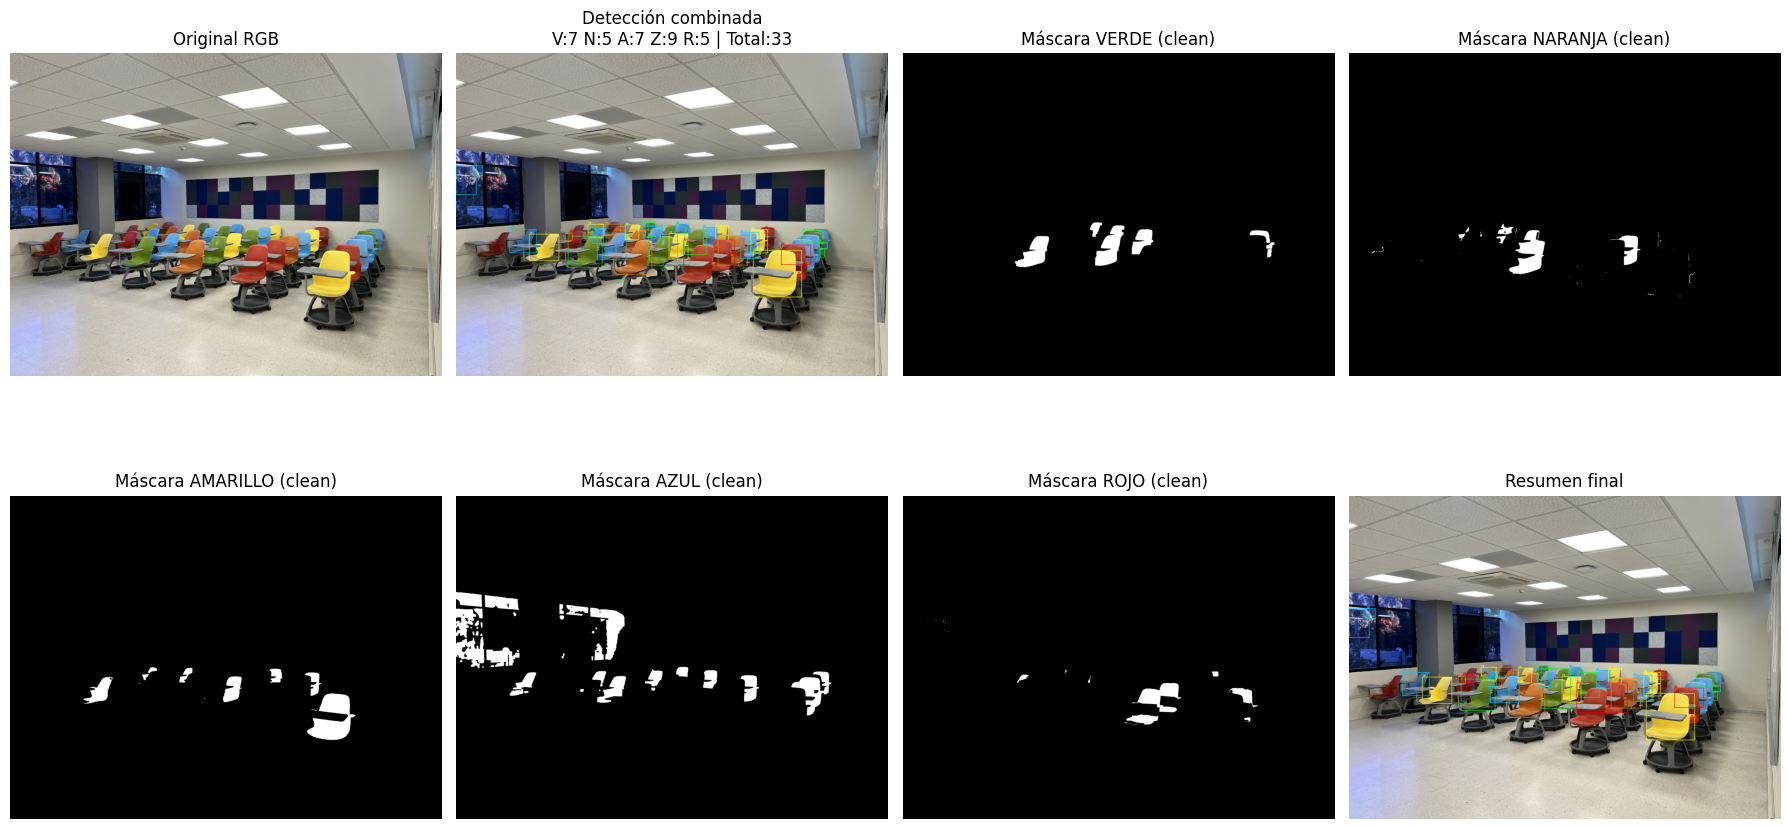

In [ ]:
#Contador de sillas por color: verde, naranja, amarillo, azul, rojo

 # - conteo por color
 # - total global
 # - figura resumen con bounding boxes combinados

  #Requisitos:
      #pip install opencv-python numpy matplotlib

from __future__ import annotations

from dataclasses import dataclass
from typing import List, Tuple, Dict

import cv2
import numpy as np
import matplotlib.pyplot as plt



#Imagen para Analizar

IMAGE_PATH = (
    "/content/drive/MyDrive/Semestre5SemanaTec2/"
    "Evidencia FINAL/IMG_EVIDENCIA/IMG_4.jpg"
)


@dataclass
class ColorSpec:

    #Especificación para detección de sillas de un color dado.

   # Atributos importantes:
   # - hsv_ranges: lista de (low, high) en HSV. Para colores tipo rojo que
   #   "cruzan" el hue 180°, damos dos rangos.
   # - draw_bgr: color de dibujo para las cajas.
   #  - merge_iou: si >0, fusiona cajas que se traslapan para no contar respaldo+asiento doble.

    name: str
    hsv_ranges: List[Tuple[np.ndarray, np.ndarray]]
    draw_bgr: Tuple[int, int, int]
    min_area: int = 800
    max_area: int | None = None
    aspect_min: float = 0.4
    aspect_max: float = 2.0
    min_h: int = 0

    # Morfología base
    close_kernel: Tuple[int, int] = (5, 5)
    close_iter: int = 2
    open_kernel: Tuple[int, int] = (3, 3)
    open_iter: int = 1

    # Extra opcional (dilatación, erosión)
    dilate_kernel: Tuple[int, int] | None = None
    dilate_iter: int = 0
    erode_kernel: Tuple[int, int] | None = None
    erode_iter: int = 0

    # Fusión de cajas por IoU
    merge_iou: float = 0.0


def make_mask(
    hsv_img: np.ndarray,
    ranges: List[Tuple[np.ndarray, np.ndarray]]
) -> np.ndarray:

    # Combina varios rangos HSV en una sola máscara binaria.

    masks = [cv2.inRange(hsv_img, low, high) for (low, high) in ranges]
    mask_out = masks[0].copy()
    for m in masks[1:]:
        mask_out = cv2.bitwise_or(mask_out, m)
    return mask_out


def clean_mask(mask_in: np.ndarray, spec: ColorSpec) -> np.ndarray:

   # Aplica operaciones morfológicas definidas en el spec:
   # close -> open -> dilate -> erode (si están configuradas).

    mask = mask_in

    if spec.close_iter > 0:
        k_close = np.ones(spec.close_kernel, np.uint8)
        mask = cv2.morphologyEx(
            mask, cv2.MORPH_CLOSE, k_close, iterations=spec.close_iter
        )

    if spec.open_iter > 0:
        k_open = np.ones(spec.open_kernel, np.uint8)
        mask = cv2.morphologyEx(
            mask, cv2.MORPH_OPEN, k_open, iterations=spec.open_iter
        )

    if spec.dilate_kernel and spec.dilate_iter > 0:
        k_dil = np.ones(spec.dilate_kernel, np.uint8)
        mask = cv2.dilate(mask, k_dil, iterations=spec.dilate_iter)

    if spec.erode_kernel and spec.erode_iter > 0:
        k_ero = np.ones(spec.erode_kernel, np.uint8)
        mask = cv2.erode(mask, k_ero, iterations=spec.erode_iter)

    return mask


def iou(
    box_a: Tuple[int, int, int, int],
    box_b: Tuple[int, int, int, int]
) -> float:

   # Calcula Intersection over Union (IoU) entre dos bounding boxes
   # en formato (x, y, w, h).

    x_a, y_a, w_a, h_a = box_a
    x_b, y_b, w_b, h_b = box_b

    xa1, ya1, xa2, ya2 = x_a, y_a, x_a + w_a, y_a + h_a
    xb1, yb1, xb2, yb2 = x_b, y_b, x_b + w_b, y_b + h_b

    x1 = max(xa1, xb1)
    y1 = max(ya1, yb1)
    x2 = min(xa2, xb2)
    y2 = min(ya2, yb2)

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h

    if inter_area == 0:
        return 0.0

    area_a = w_a * h_a
    area_b = w_b * h_b
    union_area = area_a + area_b - inter_area
    if union_area <= 0:
        return 0.0

    return inter_area / float(union_area)


def merge_overlapping_boxes(
    boxes: List[Tuple[int, int, int, int]],
    thr: float
) -> List[Tuple[int, int, int, int]]:

   # Junta cajas que se traslapan mucho (IoU > thr). Usado en naranja
   # para unir respaldo y asiento y contarlo como una silla.

    merged: List[Tuple[int, int, int, int]] = []

    for box in boxes:
        bx, by, bw, bh = box
        did_merge = False

        for i, keep in enumerate(merged):
            if iou(box, keep) > thr:
                kx, ky, kw, kh = keep

                x_min = min(bx, kx)
                y_min = min(by, ky)
                x_max = max(bx + bw, kx + kw)
                y_max = max(by + bh, ky + kh)

                merged[i] = (x_min, y_min, x_max - x_min, y_max - y_min)
                did_merge = True
                break

        if not did_merge:
            merged.append(box)

    return merged


def find_chair_boxes(
    mask: np.ndarray,
    spec: ColorSpec
) -> List[Tuple[int, int, int, int]]:

   # Encuentra bounding boxes candidatas a sillas, filtrando por área,
   # relación de aspecto y altura mínima.

    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    boxes: List[Tuple[int, int, int, int]] = []

    for contour in contours:
        area = cv2.contourArea(contour)

        if area < spec.min_area:
            continue
        if spec.max_area is not None and area > spec.max_area:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        if h < spec.min_h:
            continue

        if h == 0:
            continue

        aspect = w / float(h)

        if not (spec.aspect_min < aspect < spec.aspect_max):
            continue

        boxes.append((x, y, w, h))

    # Cajas traslapadas (por ejemplo respaldo+asiento)
    if spec.merge_iou > 0.0 and len(boxes) > 1:
        boxes = merge_overlapping_boxes(boxes, spec.merge_iou)

    return boxes


def draw_boxes(
    base_img_rgb: np.ndarray,
    boxes: List[Tuple[int, int, int, int]],
    color_bgr: Tuple[int, int, int],
    start_idx: int = 1
) -> np.ndarray:

   # Dibuja rectángulos y numeración sobre una copia de la imagen.
   # La numeración es continua empezando en start_idx.

    out = base_img_rgb.copy()
    idx = start_idx

    for (x, y, w, h) in boxes:
        cv2.rectangle(
            out,
            (x, y),
            (x + w, y + h),
            color_bgr,
            3
        )
        cv2.putText(
            out,
            f"{idx}",
            (x, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            color_bgr,
            2,
            cv2.LINE_AA
        )
        idx += 1

    return out


def main() -> None:
    # Cargar imagen
    img_bgr = cv2.imread(IMAGE_PATH)
    if img_bgr is None:
        raise ValueError("No se pudo leer la imagen. Revisa la ruta.")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Definiciones por color

    # Verde
    green = ColorSpec(
        name="verde",
        hsv_ranges=[
            (np.array([35, 80, 50], dtype=np.uint8),
             np.array([85, 255, 255], dtype=np.uint8)),
        ],
        draw_bgr=(0, 255, 0),
        min_area=1500,
        aspect_min=0.4,
        aspect_max=2.0,
        # morph
        close_kernel=(7, 7),
        close_iter=2,
        open_kernel=(7, 7),
        open_iter=1,
        dilate_kernel=(7, 7),
        dilate_iter=2,
        merge_iou=0.0,
    )

    # Naranja (incluye 2 rangos + fusión IoU)
    orange = ColorSpec(
        name="naranja",
        hsv_ranges=[
            # naranja brillante
            (np.array([12, 140, 140], dtype=np.uint8),
             np.array([22, 255, 255], dtype=np.uint8)),
            # naranja en sombra
            (np.array([8, 80, 60], dtype=np.uint8),
             np.array([20, 255, 200], dtype=np.uint8)),
        ],
        draw_bgr=(255, 140, 0),
        min_area=800,
        aspect_min=0.4,
        aspect_max=2.0,
        close_kernel=(5, 5),
        close_iter=2,
        open_kernel=(3, 3),
        open_iter=1,
        merge_iou=0.30,  # une respaldo + asiento
    )

    # Amarillo
    yellow = ColorSpec(
        name="amarillo",
        hsv_ranges=[
            (np.array([20, 100, 100], dtype=np.uint8),
             np.array([35, 255, 255], dtype=np.uint8)),
        ],
        draw_bgr=(255, 255, 0),
        min_area=800,
        aspect_min=0.4,
        aspect_max=2.0,
        close_kernel=(5, 5),
        close_iter=2,
        open_kernel=(3, 3),
        open_iter=1,
        erode_kernel=(3, 3),
        erode_iter=1,
        merge_iou=0.0,
    )

    # Azul (más estricto para no agarrar todo)
    blue = ColorSpec(
        name="azul",
        hsv_ranges=[
            (np.array([95, 90, 90], dtype=np.uint8),
             np.array([130, 255, 255], dtype=np.uint8)),
        ],
        draw_bgr=(0, 200, 255),  # cian-ish
        min_area=2000,
        max_area=40000,
        aspect_min=0.6,
        aspect_max=1.6,
        min_h=40,
        close_kernel=(7, 7),
        close_iter=2,
        open_kernel=(7, 7),
        open_iter=1,
        dilate_kernel=(7, 7),
        dilate_iter=1,
        merge_iou=0.0,
    )

    # Rojo (dos rangos de H y erosión suave para separar sillas pegadas)
    red = ColorSpec(
        name="rojo",
        hsv_ranges=[
            # rojo bajo
            (np.array([0, 150, 150], dtype=np.uint8),
             np.array([8, 255, 255], dtype=np.uint8)),
            # rojo alto (cierra hue H cerca de 180)
            (np.array([170, 150, 150], dtype=np.uint8),
             np.array([180, 255, 255], dtype=np.uint8)),
        ],
        draw_bgr=(255, 0, 0),
        min_area=800,
        aspect_min=0.4,
        aspect_max=2.0,
        close_kernel=(5, 5),
        close_iter=2,
        open_kernel=(3, 3),
        open_iter=1,
        erode_kernel=(3, 3),
        erode_iter=1,
        merge_iou=0.0,
    )

    specs = [green, orange, yellow, blue, red]

    #Proceso por color
    per_color_boxes: Dict[str, List[Tuple[int, int, int, int]]] = {}
    per_color_masks_clean: Dict[str, np.ndarray] = {}
    composite = img_rgb.copy()

    running_idx = 1

    for spec in specs:
        # 1. máscara cruda (puede tener varios rangos HSV)
        mask_raw = make_mask(img_hsv, spec.hsv_ranges)

        # 2. máscara limpia según morfología
        mask_clean = clean_mask(mask_raw, spec)
        per_color_masks_clean[spec.name] = mask_clean

        # 3. bounding boxes candidatos a sillas
        boxes = find_chair_boxes(mask_clean, spec)
        per_color_boxes[spec.name] = boxes

        # 4. dibujar sobre el compuesto con numeración continua
        composite = draw_boxes(
            composite,
            boxes,
            spec.draw_bgr,
            start_idx=running_idx
        )

        running_idx += len(boxes)

    #Resultados
    counts = {color: len(bxs) for color, bxs in per_color_boxes.items()}
    total_count = sum(counts.values())

    print("RESULTADOS:")
    print(f"{'Verde':>9}: {counts['verde']}")
    print(f"{'Naranja':>9}: {counts['naranja']}")
    print(f"{'Amarillo':>9}: {counts['amarillo']}")
    print(f"{'Azul':>9}: {counts['azul']}")
    print(f"{'Rojo':>9}: {counts['rojo']}")
    print(f"{'TOTAL':>9}: {total_count}")

    # Visualización
    # Layout 2 filas x 4 columnas:
    # 1: Original
    # 2: Resultado combinado
    # 3..7: máscaras limpias de cada color
    # 8: texto de resumen final incrustado en imagen compuesta otra vez
    plt.figure(figsize=(18, 10))

    plt.subplot(2, 4, 1)
    plt.title("Original RGB")
    plt.imshow(img_rgb)
    plt.axis("off")

    plt.subplot(2, 4, 2)
    plt.title(
        "Detección combinada\n"
        f"V:{counts['verde']} N:{counts['naranja']} "
        f"A:{counts['amarillo']} Z:{counts['azul']} "
        f"R:{counts['rojo']} | Total:{total_count}"
    )
    plt.imshow(composite)
    plt.axis("off")

    plt.subplot(2, 4, 3)
    plt.title("Máscara VERDE (clean)")
    plt.imshow(per_color_masks_clean["verde"], cmap="gray")
    plt.axis("off")

    plt.subplot(2, 4, 4)
    plt.title("Máscara NARANJA (clean)")
    plt.imshow(per_color_masks_clean["naranja"], cmap="gray")
    plt.axis("off")

    plt.subplot(2, 4, 5)
    plt.title("Máscara AMARILLO (clean)")
    plt.imshow(per_color_masks_clean["amarillo"], cmap="gray")
    plt.axis("off")

    plt.subplot(2, 4, 6)
    plt.title("Máscara AZUL (clean)")
    plt.imshow(per_color_masks_clean["azul"], cmap="gray")
    plt.axis("off")

    plt.subplot(2, 4, 7)
    plt.title("Máscara ROJO (clean)")
    plt.imshow(per_color_masks_clean["rojo"], cmap="gray")
    plt.axis("off")

    # slot 8: simplemente volvemos a mostrar composite por estética
    plt.subplot(2, 4, 8)
    plt.title("Resumen final")
    plt.imshow(composite)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()
